In [ ]:
# ============================================================
# CELL 1 — Mount Google Drive + Import Library
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, json, time, requests, warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display
from collections import deque, Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models, callbacks, regularizers

warnings.filterwarnings('ignore')
print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print("✓ Semua library loaded")

Mounted at /content/drive
TensorFlow : 2.19.0
NumPy      : 2.0.2
✓ Semua library loaded


In [ ]:
# ============================================================
# CELL 2 — Konfigurasi (Single Source of Truth)
#
# ⚠️  HANYA ubah nilai di cell ini.
#     Cell lain referensi ke sini — jangan hardcode di tempat lain.
# ============================================================

# ── Firebase & Blynk ─────────────────────────────────────────
FIREBASE_URL = "https://nilm-deep-learning-default-rtdb.firebaseio.com/pzem_data.json"
BLYNK_TOKEN  = "w_gAoI6RWnQwj8N8dZOq9koIuHznIOAd"

# ── Path Google Drive ─────────────────────────────────────────
MODEL_DIR    = '/content/drive/MyDrive/nilm_models_v6'
MODEL_PATH   = os.path.join(MODEL_DIR, 'best_nilm_model.keras')
META_PATH    = os.path.join(MODEL_DIR, 'meta_nilm.json')
SCALER_PATH  = os.path.join(MODEL_DIR, 'scaler_nilm.pkl')
ENCODER_PATH = os.path.join(MODEL_DIR, 'label_encoder.pkl')

# ── Path CSV ──────────────────────────────────────────────────
PATH_GABUNGAN = '/content/drive/MyDrive/data_pzem_gabungan_labeled.csv'

# ── Fitur Input (v6: hapus energy, pakai derived physics features)
# ⚠️  LOCKED — jangan ubah urutan ini. Harus identik antara training & inference.
FEATURE_COLS = [
    'voltage',        # V   — tegangan jaringan
    'current',        # A   — arus beban
    'power',          # W   — daya aktif (discriminator utama)
    'power_factor',   # 0-1 — tipe beban (resistif vs induktif)
    'frequency',      # Hz  — frekuensi jaringan
    'apparent_power', # VA  — daya semu = V*I
    'reactive_power', # VAR — daya reaktif (bergantung pf)
    'power_ratio',    # -   — power/apparent_power (normalized signature)
]
N_FEATURES = len(FEATURE_COLS)

# ── Hyperparameter Training ───────────────────────────────────
WINDOW_SIZE = 99      # sampel per window
STRIDE      = 5       # sliding window stride

# ── Label Kelas ───────────────────────────────────────────────
CLASSES = [
    'amplifier',
    'charger_hp',
    'charger_hp+amplifier',
    'charger_laptop',
    'dispenser',
    'hair_dryer',
    'hairdryer+dispenser',
    'hp+laptop',
    'kipas_angin',
    'kipas_angin+amplifier+charger_laptop',
    'laptop+dispenser',
    'setrika',
]

# ── Batas Fisik PZEM-004T ─────────────────────────────────────
PHYS_BOUNDS = {
    'voltage'     : (80.0,  260.0),
    'current'     : (0.0,   100.0),
    'power'       : (0.0,  3000.0),
    'frequency'   : (45.0,   65.0),
    'power_factor': (0.0,     1.0),
}

# ── Parameter Inference ───────────────────────────────────────
CONFIDENCE_THRESH = 0.55   # turunkan sedikit dari 0.60 agar lebih sensitif
SMOOTH_N          = 7      # voting window
NOISE_FLOOR_W     = 5.0    # W — bawah ini dianggap standby

# ── Hybrid Rule-based Ranges (W) — NON-OVERLAPPING ───────────
# Setiap range dipersempit agar tidak tumpang tindih
POWER_RULES = {
    (1,   20)  : ['charger_hp', 'amplifier'],
    (20,  60)  : ['charger_hp+amplifier', 'charger_laptop', 'kipas_angin'],
    (60,  200) : ['kipas_angin', 'charger_laptop', 'kipas_angin+amplifier+charger_laptop'],
    (200, 450) : ['dispenser', 'hairdryer+dispenser', 'laptop+dispenser', 'hp+laptop'],
    (450, 700) : ['hair_dryer', 'setrika'],
    (700, 9999): ['setrika', 'hair_dryer'],
}

print("✓ Konfigurasi loaded (v6)")
print(f"  Features ({N_FEATURES}) : {FEATURE_COLS}")
print(f"  Window   : {WINDOW_SIZE}  |  Stride : {STRIDE}")
print(f"  Classes  ({len(CLASSES)}) : {CLASSES}")
print(f"  Conf thr : {CONFIDENCE_THRESH*100:.0f}%  |  Smooth N : {SMOOTH_N}")
print()
print("⚠️  CATATAN v6: 'energy' dihapus dari fitur karena kumulatif")
print("    → apparent_power, reactive_power, power_ratio dipakai sebagai gantinya")

✓ Konfigurasi loaded (v6)
  Features (8) : ['voltage', 'current', 'power', 'power_factor', 'frequency', 'apparent_power', 'reactive_power', 'power_ratio']
  Window   : 99  |  Stride : 5
  Classes  (12) : ['amplifier', 'charger_hp', 'charger_hp+amplifier', 'charger_laptop', 'dispenser', 'hair_dryer', 'hairdryer+dispenser', 'hp+laptop', 'kipas_angin', 'kipas_angin+amplifier+charger_laptop', 'laptop+dispenser', 'setrika']
  Conf thr : 55%  |  Smooth N : 7

⚠️  CATATAN v6: 'energy' dihapus dari fitur karena kumulatif
    → apparent_power, reactive_power, power_ratio dipakai sebagai gantinya


In [ ]:
# ============================================================
# CELL 3 — Load Data CSV Gabungan
# ============================================================

df_labeled = None

print("=== CEK FILE ===")
if os.path.exists(PATH_GABUNGAN):
    df_labeled = pd.read_csv(PATH_GABUNGAN)
    print(f"✓ Load dari: {PATH_GABUNGAN}")
    print(f"  Baris   : {len(df_labeled)}")
    print(f"  Kolom   : {list(df_labeled.columns)}")
    print(f"\n=== DISTRIBUSI LABEL ===")
    print(df_labeled['label'].value_counts().to_string())
    print(f"\n  Unlabeled (jeda): {(df_labeled['label']=='unlabeled').sum()} baris")
    display(df_labeled.head(3))
else:
    print(f"✗ File tidak ditemukan: {PATH_GABUNGAN}")
    print("  → Upload file ke Google Drive lalu sesuaikan PATH_GABUNGAN di Cell 2.")

=== CEK FILE ===
✓ Load dari: /content/drive/MyDrive/data_pzem_gabungan_labeled.csv
  Baris   : 12436
  Kolom   : ['current', 'energy', 'frequency', 'power', 'power_factor', 'timestamp', 'voltage', 'label']

=== DISTRIBUSI LABEL ===
label
charger_hp                              4329
charger_laptop                          1229
kipas_angin                              863
hair_dryer                               863
kipas_angin+amplifier+charger_laptop     861
amplifier                                854
charger_hp+amplifier                     841
unlabeled                                712
setrika                                  569
laptop+dispenser                         368
dispenser                                345
hp+laptop                                338
hairdryer+dispenser                      264

  Unlabeled (jeda): 712 baris


,current,energy,frequency,power,power_factor,timestamp,voltage,label
0,0.161,0.320,50.0,20.1,0.59,9.0,212.80000,charger_hp
1,0.047,0.411,50.0,4.6,0.47,9.0,209.70000,charger_hp
2,0.000,0.375,50.0,0.0,0.00,9.0,210.89999,charger_hp


⚠ Ditemukan 6 outlier power > 3000W:
           power       label
233  420997760.0  charger_hp
59   420997760.0  charger_hp
91   420578336.0  charger_hp
95   417642304.0  charger_hp
17   416803456.0  charger_hp
48   202893936.0  charger_hp


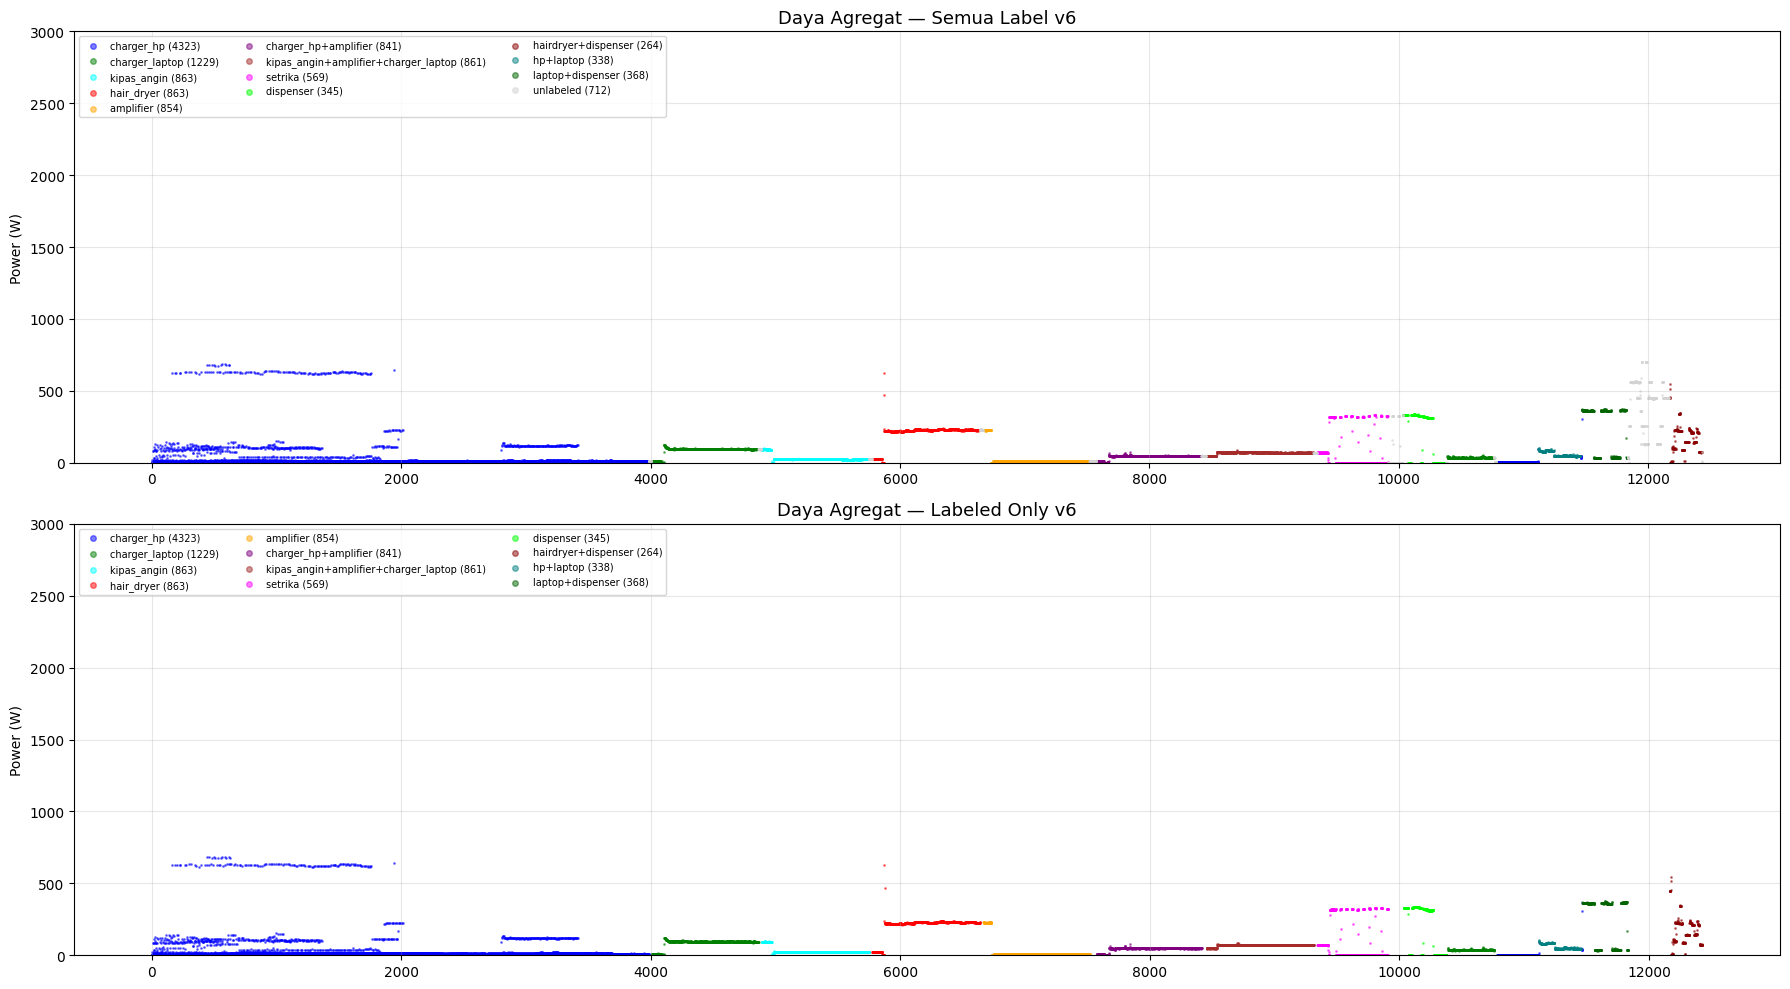

✓ Visualisasi tersimpan


In [ ]:
# ============================================================
# CELL 4 — Visualisasi Data (opsional)
# ============================================================

if df_labeled is None:
    print("✗ Jalankan Cell 3 dulu!")
else:
    COLOR_MAP = {
        'charger_hp'                          : 'blue',
        'charger_laptop'                      : 'green',
        'kipas_angin'                         : 'cyan',
        'hair_dryer'                          : 'red',
        'amplifier'                           : 'orange',
        'charger_hp+amplifier'                : 'purple',
        'kipas_angin+amplifier+charger_laptop': 'brown',
        'setrika'                             : 'magenta',
        'dispenser'                           : 'lime',
        'hairdryer+dispenser'                 : 'darkred',
        'hp+laptop'                           : 'teal',
        'laptop+dispenser'                    : 'darkgreen',
        'unlabeled'                           : 'lightgray',
    }

    POWER_VIZ_MAX = 3000
    outliers = df_labeled[df_labeled['power'] > POWER_VIZ_MAX]
    if len(outliers) > 0:
        print(f"⚠ Ditemukan {len(outliers)} outlier power > {POWER_VIZ_MAX}W:")
        print(outliers[['power', 'label']].sort_values('power', ascending=False).head(10).to_string())

    df_viz = df_labeled[df_labeled['power'] <= POWER_VIZ_MAX]
    fig, axes = plt.subplots(2, 1, figsize=(18, 10))

    for ax_idx, (ax, exclude_unl) in enumerate(zip(axes, [False, True])):
        title = 'Semua Label' if not exclude_unl else 'Labeled Only'
        ax.set_title(f'Daya Agregat — {title} v6', fontsize=13)
        df_plot = df_viz if not exclude_unl else df_viz[df_viz['label'] != 'unlabeled']
        for lbl, color in COLOR_MAP.items():
            if exclude_unl and lbl == 'unlabeled':
                continue
            mask = df_plot['label'] == lbl
            if mask.sum() > 0:
                ax.scatter(df_plot.index[mask], df_plot.loc[mask, 'power'],
                           c=color, s=1, alpha=0.5, label=f"{lbl} ({mask.sum()})")
        ax.legend(loc='upper left', fontsize=7, ncol=3, markerscale=4)
        ax.set_ylabel('Power (W)')
        ax.set_ylim(0, POWER_VIZ_MAX)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    os.makedirs(MODEL_DIR, exist_ok=True)
    plt.savefig(os.path.join(MODEL_DIR, 'visualisasi_labeled_v6.png'), dpi=150)
    plt.show()
    print("✓ Visualisasi tersimpan")

In [ ]:
# ============================================================
# CELL 5 — Clean + Feature Engineering
#
# FIX v6:
#   - 'energy' DIHAPUS dari fitur (nilai kumulatif = tidak konsisten realtime)
#   - apparent_power, reactive_power, power_ratio sebagai gantinya
#   - FEATURE_COLS tidak di-override di sini (sudah fix dari Cell 2)
# ============================================================

if df_labeled is None:
    print("✗ Jalankan Cell 3 dulu!")
else:
    # ── 0. Filter data valid ──────────────────────────────────
    df_work = df_labeled[df_labeled['label'] != 'unlabeled'].copy()
    print(f"Data awal (tanpa unlabeled): {len(df_work)}")

    # ── 1. Hard filter fisik ──────────────────────────────────
    df_work = df_work[df_work['power'] <= PHYS_BOUNDS['power'][1]].copy()
    df_work = df_work[df_work['voltage'].between(*PHYS_BOUNDS['voltage'])].copy()
    df_work = df_work[df_work['current'].between(*PHYS_BOUNDS['current'])].copy()
    df_work = df_work[df_work['power_factor'].between(*PHYS_BOUNDS['power_factor'])].copy()
    df_work = df_work[df_work['frequency'].between(*PHYS_BOUNDS['frequency'])].copy()
    print(f"Setelah hard filter fisik   : {len(df_work)}")

    # ── 2. Trim tepi transisi ─────────────────────────────────
    def trim_transition_edges(df, n=10):
        dfs = []
        for lbl in df['label'].unique():
            grp = df[df['label'] == lbl]
            if len(grp) > 2 * n:
                grp = grp.iloc[n:-n]
            dfs.append(grp)
        return pd.concat(dfs).reset_index(drop=True)

    df_work = trim_transition_edges(df_work)

    # ── 3. Power minimum per kelas ────────────────────────────
    POWER_MIN = {
        'charger_hp'                          : 3,
        'charger_laptop'                      : 30,
        'kipas_angin'                         : 10,
        'hair_dryer'                          : 100,
        'amplifier'                           : 1,
        'setrika'                             : 300,   # ← fix: setrika > 300W
        'dispenser'                           : 10,
        'hairdryer+dispenser'                 : 80,
        'hp+laptop'                           : 20,
        'laptop+dispenser'                    : 80,
        'charger_hp+amplifier'                : 5,
        'kipas_angin+amplifier+charger_laptop': 50,
    }
    for lbl, min_pw in POWER_MIN.items():
        df_work = df_work[
            ~((df_work['label'] == lbl) & (df_work['power'] < min_pw))
        ]
    df_work = df_work.reset_index(drop=True)
    print(f"Setelah power min filter    : {len(df_work)}")

    # ── 4. IQR filter per kelas ───────────────────────────────
    def iqr_filter(df, col='power', factor=2.5):
        dfs = []
        for lbl in df['label'].unique():
            grp = df[df['label'] == lbl]
            Q1, Q3 = grp[col].quantile(0.25), grp[col].quantile(0.75)
            IQR = Q3 - Q1
            grp = grp[
                (grp[col] >= Q1 - factor * IQR) &
                (grp[col] <= Q3 + factor * IQR)
            ]
            dfs.append(grp)
        return pd.concat(dfs).reset_index(drop=True)

    df_work = iqr_filter(df_work)
    print(f"Setelah IQR filter          : {len(df_work)}")

    # ── 5. Feature engineering (physics-based) ───────────────
    # ⚠️  HARUS IDENTIK dengan build_feature_vector() di Cell inference
    df_work['apparent_power'] = df_work['voltage'] * df_work['current']
    df_work['reactive_power'] = df_work['apparent_power'] * np.sqrt(
        np.maximum(0, 1 - df_work['power_factor'] ** 2)
    )
    df_work['power_ratio'] = df_work['power'] / (df_work['apparent_power'] + 1e-6)

    # ── 6. Validasi semua fitur ada ───────────────────────────
    missing = [f for f in FEATURE_COLS if f not in df_work.columns]
    if missing:
        raise ValueError(f"❌ Fitur hilang dari DataFrame: {missing}")

    df_norm = df_work.copy()

    print(f"\n✓ Feature engineering selesai")
    print(f"  Total data  : {len(df_norm)}")
    print(f"  Fitur ({N_FEATURES})  : {FEATURE_COLS}")
    print()

    # Ringkasan power per kelas untuk validasi
    print("=== POWER RANGE PER KELAS ===")
    summary = df_norm.groupby('label')['power'].agg(['count','min','mean','max']).round(1)
    print(summary.to_string())
    print("\n✓ df_norm siap → lanjut Cell 6")

Data awal (tanpa unlabeled): 11724
Setelah hard filter fisik   : 11718
Setelah power min filter    : 9974
Setelah IQR filter          : 8966

✓ Feature engineering selesai
  Total data  : 8966
  Fitur (8)  : ['voltage', 'current', 'power', 'power_factor', 'frequency', 'apparent_power', 'reactive_power', 'power_ratio']

=== POWER RANGE PER KELAS ===
                                      count    min   mean    max
label                                                           
amplifier                               727   10.0   10.2   10.5
charger_hp                             3101    3.0   12.0   37.9
charger_hp+amplifier                    687   44.9   48.0   50.8
charger_laptop                         1120   33.1   76.9  122.8
dispenser                               187  289.4  324.5  336.2
hair_dryer                              755  214.0  226.8  238.5
hairdryer+dispenser                     210   85.6  181.3  346.5
hp+laptop                               318   42.9   60.8   95.7

In [ ]:
# ============================================================
# CELL 6 — Label Encoding + Sliding Window + Scaling + Split
#
# FIX v6:
#   - Scaler disimpan ke MODEL_DIR (Google Drive) agar tidak hilang
#   - Encoder disimpan ke MODEL_DIR
#   - Sliding window per-kelas (tidak cross-label)
# ============================================================

if 'df_norm' not in dir() or df_norm is None:
    print("✗ Jalankan Cell 5 dulu!")
else:
    # ── 1. Label Encoding ─────────────────────────────────────
    le = LabelEncoder()
    df_norm['label_enc'] = le.fit_transform(df_norm['label'])
    N_CLASS = len(le.classes_)

    print("=== LABEL ENCODING ===")
    for i, cls in enumerate(le.classes_):
        cnt = (df_norm['label_enc'] == i).sum()
        print(f"  {i:2d} -> {cls:<45} ({cnt} sampel)")

    # ── 2. Sliding Window PER KELAS ──────────────────────────
    # ⚠️  PENTING: sliding window per kelas mencegah window cross-label
    #     yang membuat majority voting tidak akurat
    feat_arr  = df_norm[FEATURE_COLS].values.astype('float32')
    label_arr = df_norm['label_enc'].values.astype('int32')

    X_list, y_list = [], []
    for lbl_id in range(N_CLASS):
        idx_lbl = np.where(label_arr == lbl_id)[0]
        if len(idx_lbl) < WINDOW_SIZE:
            print(f"  ⚠ Kelas {lbl_id} ({le.classes_[lbl_id]}) hanya {len(idx_lbl)} sampel < window {WINDOW_SIZE}, skip")
            continue
        # ambil sub-array kelas ini
        feat_lbl = feat_arr[idx_lbl]
        for start in range(0, len(feat_lbl) - WINDOW_SIZE + 1, STRIDE):
            X_list.append(feat_lbl[start : start + WINDOW_SIZE])
            y_list.append(lbl_id)

    X = np.array(X_list, dtype='float32')
    y = np.array(y_list,  dtype='int32')
    print(f"\n✓ Windows: X={X.shape}  y={y.shape}")

    # ── 3. Train / Val Split ──────────────────────────────────
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"  Train : {X_train.shape[0]}  |  Val : {X_val.shape[0]}")

    # ── 4. Scaling (fit pada train, transform keduanya) ───────
    scaler = StandardScaler()
    X_train_2d = X_train.reshape(-1, X_train.shape[-1])
    X_val_2d   = X_val.reshape(-1, X_val.shape[-1])

    X_train_scaled = scaler.fit_transform(X_train_2d)
    X_val_scaled   = scaler.transform(X_val_2d)

    X_train = X_train_scaled.reshape(X_train.shape)
    X_val   = X_val_scaled.reshape(X_val.shape)

    # ── 5. Simpan Scaler & Encoder ke Drive ──────────────────
    os.makedirs(MODEL_DIR, exist_ok=True)
    joblib.dump(scaler, SCALER_PATH)
    joblib.dump(le,     ENCODER_PATH)
    print(f"✓ Scaler  disimpan: {SCALER_PATH}")
    print(f"✓ Encoder disimpan: {ENCODER_PATH}")

    # ── 6. Augmentasi kelas minor ─────────────────────────────
    def augment_minority_classes(X, y, noise_std=0.01, target_ratio=0.6):
        counts = Counter(y)
        max_count = max(counts.values())
        threshold = int(target_ratio * max_count)
        X_aug, y_aug = list(X), list(y)
        for cls_id, cnt in counts.items():
            if cnt < threshold:
                needed = threshold - cnt
                idx = np.where(y == cls_id)[0]
                if len(idx) == 0:
                    continue
                chosen = np.random.choice(idx, needed, replace=True)
                noise  = np.random.normal(0, noise_std, X[chosen].shape).astype('float32')
                X_aug.extend(X[chosen] + noise)
                y_aug.extend([cls_id] * needed)
                print(f"  Augment [{cls_id:2d}] {le.classes_[cls_id][:30]:30s}: {cnt} → {cnt+needed}")
        return np.array(X_aug, dtype='float32'), np.array(y_aug, dtype='int32')

    print("\n=== AUGMENTASI KELAS MINOR (target_ratio=0.6) ===")
    X_train, y_train = augment_minority_classes(X_train, y_train, noise_std=0.01, target_ratio=0.6)
    print(f"  Train setelah augment: {X_train.shape[0]} sampel")

    # ── 7. Class weights ──────────────────────────────────────
    cw_arr  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    cw_dict = dict(enumerate(cw_arr))
    print(f"\n  Class weights: { {k: round(v,3) for k,v in cw_dict.items()} }")

    # ── 8. Validasi ───────────────────────────────────────────
    print("\n=== VALIDASI FEATURE ===")
    print(f"X_train range: [{X_train.min():.3f}, {X_train.max():.3f}]")
    print(f"X_val range  : [{X_val.min():.3f}, {X_val.max():.3f}]")
    print("Sample window[0][0]:", X_train[0, 0, :])
    print("\n✓ Cell 6 selesai → lanjut Cell 7 (Training)")

=== LABEL ENCODING ===
   0 -> amplifier                                     (727 sampel)
   1 -> charger_hp                                    (3101 sampel)
   2 -> charger_hp+amplifier                          (687 sampel)
   3 -> charger_laptop                                (1120 sampel)
   4 -> dispenser                                     (187 sampel)
   5 -> hair_dryer                                    (755 sampel)
   6 -> hairdryer+dispenser                           (210 sampel)
   7 -> hp+laptop                                     (318 sampel)
   8 -> kipas_angin                                   (752 sampel)
   9 -> kipas_angin+amplifier+charger_laptop          (754 sampel)
  10 -> laptop+dispenser                              (223 sampel)
  11 -> setrika                                       (132 sampel)

✓ Windows: X=(1562, 99, 8)  y=(1562,)
  Train : 1249  |  Val : 313
✓ Scaler  disimpan: /content/drive/MyDrive/nilm_models_v6/scaler_nilm.pkl
✓ Encoder disimpan: /content/

In [ ]:
print("Shape X_train:", X_train.shape)

# cek sample fitur pertama
print("\nSample fitur (1 window, timestep pertama):")
print(X_train[0,0,:])

# cek apakah fitur beda atau sama
import pandas as pd
df_check = pd.DataFrame(X_train.reshape(-1, X_train.shape[-1]))
print("\nStatistik fitur:")
print(df_check.describe())

Shape X_train: (3649, 99, 8)

Sample fitur (1 window, timestep pertama):
[ 1.6022787  -0.06709269 -0.10341275  0.37223402  0.41878223 -0.04224916
  1.3018014   0.38703126]

Statistik fitur:
                   0              1              2              3  \
count  361251.000000  361251.000000  361251.000000  361251.000000   
mean        0.247707       0.916194       0.918483       0.600401   
std         1.042580       1.589613       1.598540       0.936342   
min        -3.426186      -0.800580      -0.722390      -2.342235   
25%        -0.561296      -0.362024      -0.471352      -0.134522   
50%         0.237772       0.098081       0.126005       0.992137   
75%         1.046369       2.103508       2.128376       1.491647   
max         2.755946       3.855685       3.902732       1.549151   

                   4              5              6              7  
count  361251.000000  361251.000000  361251.000000  361251.000000  
mean       -0.106742       0.928083       0.066061  

In [ ]:
# ============================================================
# CELL 7 — Arsitektur CNN-BiLSTM-Attention + Training
# ============================================================

if 'X_train' not in dir():
    print("✗ Jalankan Cell 6 dulu!")
else:
    def build_nilm_model(window, n_feat, n_cls):
        L2  = 1e-4
        inp = layers.Input(shape=(window, n_feat), name='input')

        # ── CNN Block 1 ───────────────────────────────────────
        x = layers.Conv1D(64, 3, padding='same', activation='relu',
                          kernel_regularizer=regularizers.l2(L2))(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(64, 3, padding='same', activation='relu',
                          kernel_regularizer=regularizers.l2(L2))(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Dropout(0.3)(x)

        # ── CNN Block 2 ───────────────────────────────────────
        x = layers.Conv1D(128, 3, padding='same', activation='relu',
                          kernel_regularizer=regularizers.l2(L2))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(128, 3, padding='same', activation='relu',
                          kernel_regularizer=regularizers.l2(L2))(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Dropout(0.3)(x)

        # ── Self-Attention ────────────────────────────────────
        attn         = layers.Dense(64, activation='tanh')(x)
        attn_scores  = layers.Dense(1)(attn)
        attn_weights = layers.Softmax(axis=1)(attn_scores)
        x = layers.Multiply()([x, attn_weights])

        # ── BiLSTM ────────────────────────────────────────────
        x = layers.Bidirectional(
            layers.LSTM(64, return_sequences=False,
                        kernel_regularizer=regularizers.l2(L2)),
            name='bilstm'
        )(x)
        x = layers.Dropout(0.4)(x)

        # ── Dense head ────────────────────────────────────────
        x   = layers.Dense(128, activation='relu',
                            kernel_regularizer=regularizers.l2(L2))(x)
        x   = layers.Dropout(0.4)(x)
        out = layers.Dense(n_cls, activation='softmax', name='output')(x)

        model = models.Model(inp, out, name='nilm_cnn_bilstm_attn_v6')
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
            loss='sparse_categorical_crossentropy',
            metrics=[
                'accuracy',
                tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')
            ]
        )
        return model

    model = build_nilm_model(WINDOW_SIZE, N_FEATURES, N_CLASS)
    model.summary()

    # ── Callbacks ─────────────────────────────────────────────
    os.makedirs(MODEL_DIR, exist_ok=True)
    EPOCHS = 120

    cb_list = [
        callbacks.ModelCheckpoint(
            MODEL_PATH,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.4,
            patience=8,
            min_lr=1e-6,
            verbose=1
        ),
        tf.keras.callbacks.LearningRateScheduler(
            lambda epoch: 1e-6 + 0.5 * (3e-4 - 1e-6) * (1 + np.cos(np.pi * epoch / EPOCHS)),
            verbose=0
        ),
    ]

    print(f"\n=== MULAI TRAINING v6 ({EPOCHS} epochs, {N_CLASS} kelas, {N_FEATURES} fitur) ===")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=64,
        class_weight=cw_dict,
        callbacks=cb_list,
        verbose=1
    )
    print("=== TRAINING SELESAI ===")

Model: "nilm_cnn_bilstm_attn_v6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 99, 8)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 99, 64)    │      1,600 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 99, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 99, 64)    │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 99, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 49, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 49, 64)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 49, 128)   │     24,704 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 49, 128)   │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 49, 128)   │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 49, 128)   │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 24, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 128)   │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24, 64)    │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 24, 1)     │         65 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 24, 1)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 24, 128)   │          0 │ dropout_1[0][0],  │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 128)       │     98,816 │ multiply[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ bilstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]   

 Total params: 214,669 (838.55 KB)

 Trainable params: 213,901 (835.55 KB)

 Non-trainable params: 768 (3.00 KB)


=== MULAI TRAINING v6 (120 epochs, 12 kelas, 8 fitur) ===
Epoch 1/120
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3219 - loss: 2.4109 - top3_acc: 0.6331
Epoch 1: val_accuracy improved from None to 0.17252, saving model to /content/drive/MyDrive/nilm_models_v6/best_nilm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/nilm_models_v6/best_nilm_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.4489 - loss: 2.2213 - top3_acc: 0.8052 - val_accuracy: 0.1725 - val_loss: 2.3666 - val_top3_acc: 0.9201 - learning_rate: 3.0000e-04
Epoch 2/120
55/58 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6963 - loss: 1.3262 - top3_acc: 0.9672
Epoch 2: val_accuracy improved from 0.17252 to 0.45687, saving model to /content/drive/MyDrive/nilm_models_v6/best_nilm_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/nilm_models_v6/best_nilm_model.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7873 - loss: 1.0133 - top3_acc: 0.9808 

In [ ]:
# ============================================================
# CELL 8 — Simpan Metadata + Evaluasi
#
# FIX v6:
#   - Tidak pakai feat_mean/feat_std lama
#   - Metadata simpan scaler_mean_ dan scaler_scale_ dari StandardScaler
#   - Scaler & encoder sudah disimpan di Cell 6 ke Drive
# ============================================================

if 'model' not in dir() or 'history' not in dir():
    print("✗ Jalankan Cell 7 dulu!")
elif 'scaler' not in dir() or 'le' not in dir():
    print("✗ Jalankan Cell 6 dulu! (scaler/le tidak ada)")
else:
    # ── Simpan metadata ───────────────────────────────────────
    meta = {
        'feature_cols'   : FEATURE_COLS,
        'scaler_mean'    : scaler.mean_.tolist(),      # ← dari StandardScaler
        'scaler_scale'   : scaler.scale_.tolist(),     # ← dari StandardScaler
        'window_size'    : WINDOW_SIZE,
        'n_features'     : N_FEATURES,
        'stride'         : STRIDE,
        'classes'        : list(le.classes_),
        'n_classes'      : N_CLASS,
        'noise_floor_w'  : NOISE_FLOOR_W,
        'conf_thresh'    : CONFIDENCE_THRESH,
        'model_version'  : 'v6',
    }
    os.makedirs(MODEL_DIR, exist_ok=True)
    with open(META_PATH, 'w') as f:
        json.dump(meta, f, indent=2)

    print(f"✓ Model   : {MODEL_PATH}")
    print(f"✓ Meta    : {META_PATH}")
    print(f"✓ Scaler  : {SCALER_PATH}")
    print(f"✓ Encoder : {ENCODER_PATH}")
    print(f"\n--- Metadata ---")
    print(json.dumps(meta, indent=2))

    # ── Validasi konsistensi ──────────────────────────────────
    print("\n=== VALIDASI KONSISTENSI ===")
    print(f"  Model input  : {model.input_shape}")
    print(f"  Model output : {model.output_shape}")
    assert model.input_shape == (None, WINDOW_SIZE, N_FEATURES), "❌ Input shape mismatch!"
    assert model.output_shape == (None, N_CLASS), "❌ Output shape mismatch!"
    print("  ✓ Shape konsisten")

    # ── Classification Report ─────────────────────────────────
    y_pred = model.predict(X_val, verbose=0).argmax(axis=1)
    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(y_val, y_pred, target_names=le.classes_))

    # ── Confusion Matrix ──────────────────────────────────────
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
    plt.title('Confusion Matrix — NILM v6')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right'); plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrix_v6.png'), dpi=150)
    plt.show()

    # ── Training History ──────────────────────────────────────
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4))
    a1.plot(history.history['accuracy'],     label='Train')
    a1.plot(history.history['val_accuracy'], label='Val')
    a1.set_title('Accuracy v6'); a1.legend(); a1.grid(True)
    a2.plot(history.history['loss'],     label='Train')
    a2.plot(history.history['val_loss'], label='Val')
    a2.set_title('Loss v6'); a2.legend(); a2.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'training_history_v6.png'), dpi=150)
    plt.show()
    print("✓ Grafik evaluasi tersimpan")

✗ Jalankan Cell 7 dulu!


In [ ]:
# ============================================================
# CELL 9 — Load Model + Scaler + Encoder dari Drive
#
# ⚠️  Jalankan cell ini jika ingin INFERENCE SAJA tanpa retrain.
#     Jika habis training, variabel sudah ada di memori (skip cell ini).
# ============================================================

model_nilm = None
meta_inf   = None

# ── Load Model ────────────────────────────────────────────────
if os.path.exists(MODEL_PATH):
    model_nilm = tf.keras.models.load_model(MODEL_PATH)
    print(f"✓ Model loaded : {MODEL_PATH}")
    print(f"  Input shape  : {model_nilm.input_shape}")
    print(f"  Output shape : {model_nilm.output_shape}")
else:
    print(f"✗ Model tidak ditemukan: {MODEL_PATH}")
    print("  → Jalankan Cell 7 untuk training terlebih dahulu!")

# ── Load Metadata ─────────────────────────────────────────────
if os.path.exists(META_PATH):
    with open(META_PATH) as f:
        meta_inf = json.load(f)

    INF_FEATURES = meta_inf['feature_cols']
    INF_WINDOW   = meta_inf['window_size']
    INF_NFEAT    = meta_inf['n_features']
    INF_CLASSES  = meta_inf['classes']
    INF_NOISE_W  = meta_inf.get('noise_floor_w', NOISE_FLOOR_W)
    INF_CONF_THR = meta_inf.get('conf_thresh',   CONFIDENCE_THRESH)

    print(f"\n✓ Meta loaded  : {META_PATH}")
    print(f"  Versi         : {meta_inf.get('model_version','?')}")
    print(f"  Features ({INF_NFEAT}) : {INF_FEATURES}")
    print(f"  Window        : {INF_WINDOW}")
    print(f"  Classes  ({len(INF_CLASSES)}) : {INF_CLASSES}")
else:
    print(f"✗ Meta tidak ditemukan: {META_PATH}")

# ── Load Scaler & Encoder ─────────────────────────────────────
if os.path.exists(SCALER_PATH):
    scaler_inf = joblib.load(SCALER_PATH)
    print(f"✓ Scaler loaded : {SCALER_PATH}")
else:
    print(f"✗ Scaler tidak ditemukan: {SCALER_PATH}")
    scaler_inf = None

if os.path.exists(ENCODER_PATH):
    le_inf = joblib.load(ENCODER_PATH)
    print(f"✓ Encoder loaded: {ENCODER_PATH}")
else:
    print(f"✗ Encoder tidak ditemukan: {ENCODER_PATH}")
    le_inf = None

# ── Validasi Konsistensi ──────────────────────────────────────
if model_nilm and meta_inf and scaler_inf and le_inf:
    expected_input  = (None, INF_WINDOW, INF_NFEAT)
    actual_input    = tuple(model_nilm.input_shape)
    expected_output = (None, len(INF_CLASSES))
    actual_output   = tuple(model_nilm.output_shape)

    if actual_input == expected_input and actual_output == expected_output:
        print(f"\n✓ KONSISTEN — model input {actual_input}, output {actual_output}")
        print(f"  Scaler mean  : {scaler_inf.mean_}")
        print(f"  Encoder kelas: {list(le_inf.classes_)}")
    else:
        print(f"\n❌ MISMATCH!")
        print(f"  Model input   = {actual_input}, expected = {expected_input}")
        print(f"  Model output  = {actual_output}, expected = {expected_output}")
        print("  → Retrain atau pastikan file .keras/.pkl/.json dari versi yang sama!")
else:
    print("\n⚠ Beberapa komponen tidak lengkap — cek pesan error di atas")

✓ Model loaded : /content/drive/MyDrive/nilm_models_v6/best_nilm_model.keras
  Input shape  : (None, 99, 8)
  Output shape : (None, 12)

✓ Meta loaded  : /content/drive/MyDrive/nilm_models_v6/meta_nilm.json
  Versi         : v6
  Features (8) : ['voltage', 'current', 'power', 'power_factor', 'frequency', 'apparent_power', 'reactive_power', 'power_ratio']
  Window        : 99
  Classes  (12) : ['amplifier', 'charger_hp', 'charger_hp+amplifier', 'charger_laptop', 'dispenser', 'hair_dryer', 'hairdryer+dispenser', 'hp+laptop', 'kipas_angin', 'kipas_angin+amplifier+charger_laptop', 'laptop+dispenser', 'setrika']
✓ Scaler loaded : /content/drive/MyDrive/nilm_models_v6/scaler_nilm.pkl
✓ Encoder loaded: /content/drive/MyDrive/nilm_models_v6/label_encoder.pkl

✓ KONSISTEN — model input (None, 99, 8), output (None, 12)
  Scaler mean  : [214.65903068   0.32469712  61.58693748   0.73417781  49.9850792
  69.62892511  22.13142498   0.73404823]
  Encoder kelas: ['amplifier', 'charger_hp', 'charger_hp

In [ ]:
# ============================================================
# CELL 10 — Setup Buffer & Fungsi Inference
#
# FIX v6:
#   - Tidak ada 'energy' di build_feature_vector
#   - Scaler dari .pkl (bukan feat_mean/feat_std lama)
#   - ambil_data_terbaru() & kirim_blynk() didefinisikan di sini
#   - Deteksi transisi power untuk reset buffer otomatis
# ============================================================

# ── Cek prasyarat ─────────────────────────────────────────────
_model_ok   = 'model_nilm' in dir() and model_nilm is not None
_meta_ok    = 'meta_inf'   in dir() and meta_inf   is not None
_scaler_ok  = ('scaler_inf' in dir() and scaler_inf is not None) or ('scaler' in dir())
_encoder_ok = ('le_inf'     in dir() and le_inf     is not None) or ('le'     in dir())

# Fallback ke variabel training jika ada
if 'scaler_inf' not in dir() and 'scaler' in dir():
    scaler_inf = scaler
if 'le_inf' not in dir() and 'le' in dir():
    le_inf = le

if not (_model_ok and _meta_ok):
    print("✗ Jalankan Cell 9 (atau Cell 7 jika baru selesai training) dulu!")
else:
    # ── Parameter inference dari metadata ─────────────────────
    INF_WINDOW   = meta_inf['window_size']
    INF_FEATURES = meta_inf['feature_cols']
    INF_NFEAT    = meta_inf['n_features']
    INF_CLASSES  = meta_inf['classes']
    INF_CONF_THR = meta_inf.get('conf_thresh', CONFIDENCE_THRESH)
    INF_NOISE_W  = meta_inf.get('noise_floor_w', NOISE_FLOOR_W)

    # ── Buffer ────────────────────────────────────────────────
    buffer     = deque(maxlen=INF_WINDOW)
    pred_queue = deque(maxlen=SMOOTH_N)

    # ── Helper: safe float parse ──────────────────────────────
    def safe_float(d, key, fallback=0.0):
        try:
            v = float(d[key])
            return v if np.isfinite(v) else fallback
        except Exception:
            return fallback

    # ── Ambil data dari Firebase ──────────────────────────────
    def ambil_data_terbaru():
        try:
            resp = requests.get(FIREBASE_URL, timeout=5)
            if resp.status_code != 200:
                return None
            data = resp.json()
            if not data or not isinstance(data, dict):
                return None

            # ── FIREBASE NESTED: ambil entry dengan timestamp terbesar ──
            latest = max(data.values(), key=lambda x: x.get('timestamp', 0))

            # Validasi field wajib
            required = ['voltage', 'current', 'power', 'power_factor', 'frequency']
            if not all(k in latest for k in required):
                print(f"  ⚠ Field hilang: {[k for k in required if k not in latest]}")
                return None

            return latest

        except Exception as e:
            print(f"  ⚠ Firebase error: {e}")
            return None

    # ── Kirim ke Blynk ────────────────────────────────────────
    def kirim_blynk(pin, value):
        try:
            url = f"https://blynk.cloud/external/api/update?token={BLYNK_TOKEN}&{pin}={value}"
            resp = requests.get(url, timeout=3)
            if resp.status_code == 200:
                print(f"    Blynk OK -> {pin}={value}")
            else:
                print(f"    Blynk ERR {resp.status_code} -> {pin}")
        except Exception as e:
            print(f"    Blynk EXC: {e}")

    # ── Build feature vector (IDENTIK dengan Cell 5) ──────────
    # ⚠️  Urutan HARUS sama dengan FEATURE_COLS:
    #     ['voltage','current','power','power_factor','frequency',
    #      'apparent_power','reactive_power','power_ratio']
    def build_feature_vector(raw):
        v  = safe_float(raw, 'voltage',      220.0)
        i  = safe_float(raw, 'current',        0.0)
        p  = safe_float(raw, 'power',           0.0)
        pf = safe_float(raw, 'power_factor',    0.9)
        hz = safe_float(raw, 'frequency',      50.0)

        # Derived physics features (IDENTIK Cell 5)
        apparent_power = v * i
        reactive_power = apparent_power * np.sqrt(max(0.0, 1.0 - pf ** 2))
        power_ratio    = p / (apparent_power + 1e-6)

        return np.array([
            v, i, p, pf, hz,
            apparent_power,
            reactive_power,
            power_ratio,
        ], dtype=np.float32)

    # ── Fungsi Prediksi Utama ─────────────────────────────────
    _prev_power = None  # untuk deteksi transisi

    def prediksi_perangkat(raw):
        global _prev_power

        p_now = safe_float(raw, 'power', 0.0)

        # ── Deteksi transisi power → reset buffer ────────────
        if _prev_power is not None:
            delta = abs(p_now - _prev_power)
            if delta > 50.0:   # W — dinaikkan dari 30 → 50
                buffer.clear()
                pred_queue.clear()
                print(f"  ⚡ Transisi terdeteksi (ΔP={delta:.1f}W) — buffer direset")
        _prev_power = p_now

        # ── Standby detection ────────────────────────────────
        if p_now < INF_NOISE_W:
            buffer.clear()
            pred_queue.clear()
            return 'standby', 100.0, 0

        # ── Isi buffer ────────────────────────────────────────
        feat = build_feature_vector(raw)
        buffer.append(feat)
        buf_len = len(buffer)

        if buf_len < 20:
            return 'mengisi_buffer...', 0.0, buf_len

        # Pad buffer jika belum penuh (minimal 20 sampel)
        X_raw = np.array(buffer, dtype='float32')
        if buf_len < INF_WINDOW:
            repeat = int(np.ceil(INF_WINDOW / buf_len))
            X_pad = np.tile(X_raw, (repeat, 1))[:INF_WINDOW]
        else:
            X_pad = X_raw

        # ── Scale & Predict ───────────────────────────────────
        X = scaler_inf.transform(X_pad)                   # StandardScaler
        X = np.expand_dims(X, axis=0)                     # (1, 99, 8)

        probs = model_nilm.predict(X, verbose=0)[0]
        idx   = int(np.argmax(probs))
        conf  = float(probs[idx])
        label = le_inf.inverse_transform([idx])[0]

        # ── Smoothing (majority vote) ─────────────────────────
        pred_queue.append(label)
        final_label = max(set(pred_queue), key=pred_queue.count)

        # ── Confidence gate ───────────────────────────────────
        if conf < INF_CONF_THR:
            final_label = 'uncertain'

        # ── Rule-based sanity check ───────────────────────────
        # Jika prediksi model tidak masuk range power yang logis → tandai
        p_check = p_now
        valid_labels = []
        for (lo, hi), candidates in POWER_RULES.items():
            if lo <= p_check < hi:
                valid_labels.extend(candidates)
        if valid_labels and final_label not in valid_labels and final_label not in ['uncertain']:
            print(f"  ⚠ Rule conflict: model={final_label}, P={p_check:.1f}W valid={valid_labels}")
            # Ambil prediksi runner-up jika masuk valid_labels
            sorted_idx = np.argsort(probs)[::-1]
            for alt_idx in sorted_idx[1:4]:
                alt_label = le_inf.inverse_transform([alt_idx])[0]
                if alt_label in valid_labels:
                    final_label = alt_label
                    conf = float(probs[alt_idx])
                    print(f"  → Override ke: {final_label} ({conf*100:.1f}%)")
                    break

        return final_label, conf * 100, buf_len

    print("✓ Cell 10 siap")
    print(f"  Window    : {INF_WINDOW}")
    print(f"  Features  : {INF_NFEAT} → {INF_FEATURES}")
    print(f"  Classes   : {INF_CLASSES}")
    print(f"  Smoothing : {SMOOTH_N}")
    print(f"  Conf thr  : {INF_CONF_THR*100:.0f}%")

    # ── Validasi build_feature_vector ────────────────────────
    _dummy = {'voltage':220,'current':0.5,'power':100,'power_factor':0.9,'frequency':50}
    _fv = build_feature_vector(_dummy)
    print(f"\n  Test feature vector (dummy): {_fv}")
    assert len(_fv) == INF_NFEAT, f"❌ Feature vector length {len(_fv)} ≠ {INF_NFEAT}!"
    print(f"  ✓ Feature vector length {len(_fv)} == INF_NFEAT {INF_NFEAT}")

✓ Cell 10 siap
  Window    : 99
  Features  : 8 → ['voltage', 'current', 'power', 'power_factor', 'frequency', 'apparent_power', 'reactive_power', 'power_ratio']
  Classes   : ['amplifier', 'charger_hp', 'charger_hp+amplifier', 'charger_laptop', 'dispenser', 'hair_dryer', 'hairdryer+dispenser', 'hp+laptop', 'kipas_angin', 'kipas_angin+amplifier+charger_laptop', 'laptop+dispenser', 'setrika']
  Smoothing : 7
  Conf thr  : 55%

  Test feature vector (dummy): [220.          0.5       100.          0.9        50.        110.
  47.947887    0.9090909]
  ✓ Feature vector length 8 == INF_NFEAT 8


In [ ]:
# ============================================================
# CELL 10b — TEST ambil_data_terbaru() setelah fix Firebase nested
# ============================================================

raw = ambil_data_terbaru()
print("Data terbaru:", raw)

if raw:
    fv = build_feature_vector(raw)
    print("Feature vector:", fv)
    print("Ada nilai 0?", any(v == 0.0 for v in fv))
else:
    print("❌ Data None — cek koneksi Firebase atau struktur data")

Data terbaru: {'current': 0.603, 'energy': 0.852, 'frequency': 49.9, 'power': 115.4, 'power_factor': 0.92, 'timestamp': 467, 'voltage': 208.2}
Feature vector: [208.2          0.603      115.4          0.92        49.9
 125.5446      49.20323      0.91919523]
Ada nilai 0? False


In [ ]:
# ============================================================
# CELL 11 — Monitoring Real-time NILM
# ============================================================

if model_nilm is None or meta_inf is None:
    print("✗ Jalankan Cell 9/10 dulu!")
else:
    print("=" * 60)
    print("   NILM REALTIME MONITOR v6")
    print("=" * 60)
    print(f"   Window={INF_WINDOW} | {len(INF_CLASSES)} kelas | {INF_NFEAT} fitur")
    print("   Tekan STOP untuk menghentikan\n")

    last_ts  = None
    n_fail   = 0
    MAX_FAIL = 10

    try:
        while True:
            # ── Ambil data ────────────────────────────────────
            raw = ambil_data_terbaru()

            if raw is None:
                n_fail += 1
                print(f"⚠ Tidak ada data valid ({n_fail}/{MAX_FAIL})")
                if n_fail >= MAX_FAIL:
                    print("⚠ Reset buffer inference (koneksi bermasalah)")
                    buffer.clear()
                    pred_queue.clear()
                    n_fail = 0
                time.sleep(2)
                continue

            n_fail = 0

            # ── Cek timestamp ─────────────────────────────────
            ts = safe_float(raw, 'timestamp', -1)
            if last_ts is not None and ts == last_ts:
                print("⏳ Menunggu data baru ESP32...")
                time.sleep(1)
                continue
            last_ts = ts

            # ── Inference ─────────────────────────────────────
            label, conf, buf_len = prediksi_perangkat(raw)

            # ── Display ───────────────────────────────────────
            v  = safe_float(raw, 'voltage', 0)
            i  = safe_float(raw, 'current', 0)
            p  = safe_float(raw, 'power',   0)
            pf = safe_float(raw, 'power_factor', 0)

            status = "READY" if buf_len >= INF_WINDOW else "FILLING"

            print(f"\n[{ts:.0f}]")
            print(f"  V={v:.1f}V | I={i:.3f}A | P={p:.1f}W | PF={pf:.2f}")
            print(f"  Buffer     : {buf_len}/{INF_WINDOW} [{status}]")
            print(f"  Terdeteksi : {label}")
            print(f"  Confidence : {conf:.1f}%")

            # ── Kirim ke Blynk ────────────────────────────────
            kirim_blynk("V6", label)
            kirim_blynk("V7", f"{conf:.1f}")

            time.sleep(2)

    except KeyboardInterrupt:
        print("\n✓ Monitoring dihentikan")

   NILM REALTIME MONITOR v6
   Window=99 | 12 kelas | 8 fitur
   Tekan STOP untuk menghentikan


[33]
  V=206.9V | I=0.566A | P=108.9W | PF=0.93
  Buffer     : 2/99 [FILLING]
  Terdeteksi : mengisi_buffer...
  Confidence : 0.0%
    Blynk OK -> V6=mengisi_buffer...
    Blynk OK -> V7=0.0

[37]
  V=209.3V | I=0.470A | P=89.6W | PF=0.91
  Buffer     : 3/99 [FILLING]
  Terdeteksi : mengisi_buffer...
  Confidence : 0.0%
    Blynk OK -> V6=mengisi_buffer...
    Blynk OK -> V7=0.0

[41]
  V=209.3V | I=0.476A | P=91.1W | PF=0.91
  Buffer     : 4/99 [FILLING]
  Terdeteksi : mengisi_buffer...
  Confidence : 0.0%
    Blynk OK -> V6=mengisi_buffer...
    Blynk OK -> V7=0.0

[45]
  V=209.8V | I=0.462A | P=88.0W | PF=0.91
  Buffer     : 5/99 [FILLING]
  Terdeteksi : mengisi_buffer...
  Confidence : 0.0%
    Blynk OK -> V6=mengisi_buffer...
    Blynk OK -> V7=0.0

[49]
  V=209.6V | I=0.450A | P=85.5W | PF=0.91
  Buffer     : 6/99 [FILLING]
  Terdeteksi : mengisi_buffer...
  Confidence : 0.0%
    Blyn

In [ ]:

# Debug: print raw data mentah dari Firebase
raw = requests.get(FIREBASE_URL, timeout=5).json()
print("RAW FIREBASE:")
for k, v in raw.items():
    print(f"  '{k}' : {v}")

# Lalu cek hasil build_feature_vector:
fv = build_feature_vector(raw)
print("\nFeature vector:", fv)
print("Ada nilai 0?", any(v == 0.0 for v in fv))

RAW FIREBASE:
  '35221' : {'current': 0.532, 'energy': 0.837, 'frequency': 49.9, 'power': 103.8, 'power_factor': 0.92, 'timestamp': 35, 'voltage': 212}
  '37219' : {'current': 0.531, 'energy': 0.837, 'frequency': 49.9, 'power': 103.6, 'power_factor': 0.92, 'timestamp': 37, 'voltage': 212.10001}
  '39218' : {'current': 0.509, 'energy': 0.838, 'frequency': 49.9, 'power': 99.2, 'power_factor': 0.91, 'timestamp': 39, 'voltage': 213.2}
  '41221' : {'current': 0.508, 'energy': 0.838, 'frequency': 49.9, 'power': 99, 'power_factor': 0.91, 'timestamp': 41, 'voltage': 213.10001}
  '43219' : {'current': 0.504, 'energy': 0.838, 'frequency': 49.9, 'power': 98.7, 'power_factor': 0.92, 'timestamp': 43, 'voltage': 213}
  '45217' : {'current': 0.508, 'energy': 0.838, 'frequency': 49.9, 'power': 97.2, 'power_factor': 0.9, 'timestamp': 45, 'voltage': 213.10001}
  '47221' : {'current': 0.509, 'energy': 0.838, 'frequency': 50, 'power': 99.3, 'power_factor': 0.92, 'timestamp': 47, 'voltage': 212.89999}
  '4